Chargement du csv

In [1]:
import pyarrow
import pandas as pd
import missingno as msno

In [2]:
chunksize = 100_000
df = pd.read_csv("../../data/full_openfoodfacts_products_dataset.csv.gz", 
                 sep="\t",
                 encoding="utf-8",
                 low_memory=False,
                 nrows=100_000,
                 on_bad_lines="skip")


In [3]:
df.shape

(100000, 210)

<Axes: >

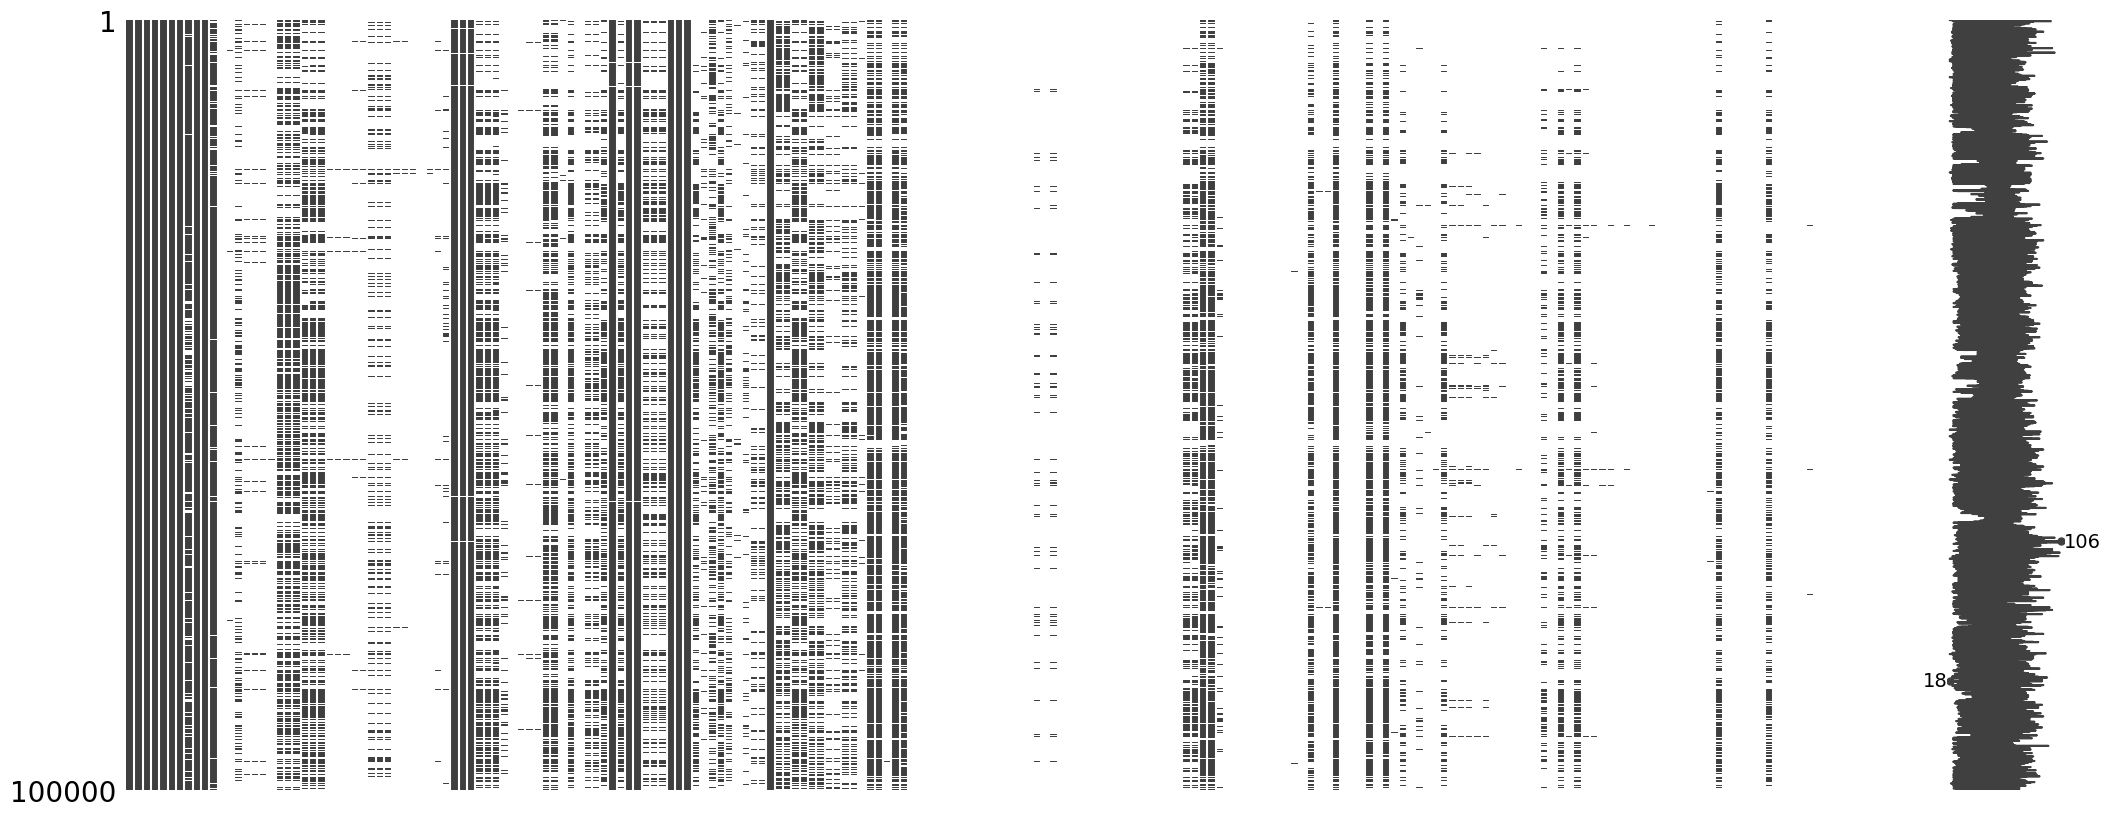

In [4]:
msno.matrix(df)

identifier pourcentage de vide pour chaques collones

In [5]:
df_len = df.shape[0]

columns_emptyness_infos = []

for column in df.columns.to_list():
    column_name = column
    empty_sum = df[column].isna().sum()
    empty_pourcentage = empty_sum / df_len * 100
    print(empty_pourcentage)

    column_emptytiness_info = {
        "column_name" : column_name,
        "empty_pourcentage" : empty_pourcentage
    }
    columns_emptyness_infos.append(column_emptytiness_info)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
12.626000000000001
0.0
0.0
5.059
99.98899999999999
98.69
72.993
96.663
96.663
96.663
99.75699999999999
40.587
40.509
40.515
45.76
44.604
44.604
98.917
98.91799999999999
98.91799999999999
98.847
98.847
83.452
83.452
83.452
99.442
99.442
99.883
100.0
99.878
98.256
93.072
0.538
0.539
0.539
45.686
45.701
44.513000000000005
86.676
100.0
99.129
98.711
98.721
38.111
38.578
99.417
45.686
100.0
65.173
65.173
52.852
0.5479999999999999
48.481
0.538
0.538
67.893
67.893
67.893
0.0
0.0
0.0
58.706
94.933
58.811
50.041999999999994
73.273
97.455
91.135
82.99
83.043
0.0
50.176
50.176
44.604
44.604
52.891
52.891
87.84100000000001
87.84100000000001
68.388
68.388
95.827
19.557
19.317
99.88
20.077
28.866000000000003
100.0
100.0
100.0
100.0
100.0
100.0
100.0
99.99900000000001
99.985
99.995
100.0
100.0
100.0
100.0
100.0
93.672
100.0
93.65400000000001
99.888
99.898
99.979
100.0
99.99900000000001
99.99900000000001
99.98899999999999
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
59.7

identification et suppression des collones trop vides

In [6]:
# reccuperer les collones trop vides
seuil = 95
collones_trop_vides = []

for column in columns_emptyness_infos:
    if column['empty_pourcentage'] >= seuil :
        collones_trop_vides.append(column['column_name'])

df_sans_collones_trop_vides = df.drop(columns=collones_trop_vides)

affichage des collones trop vides dans une matrice

<Axes: >

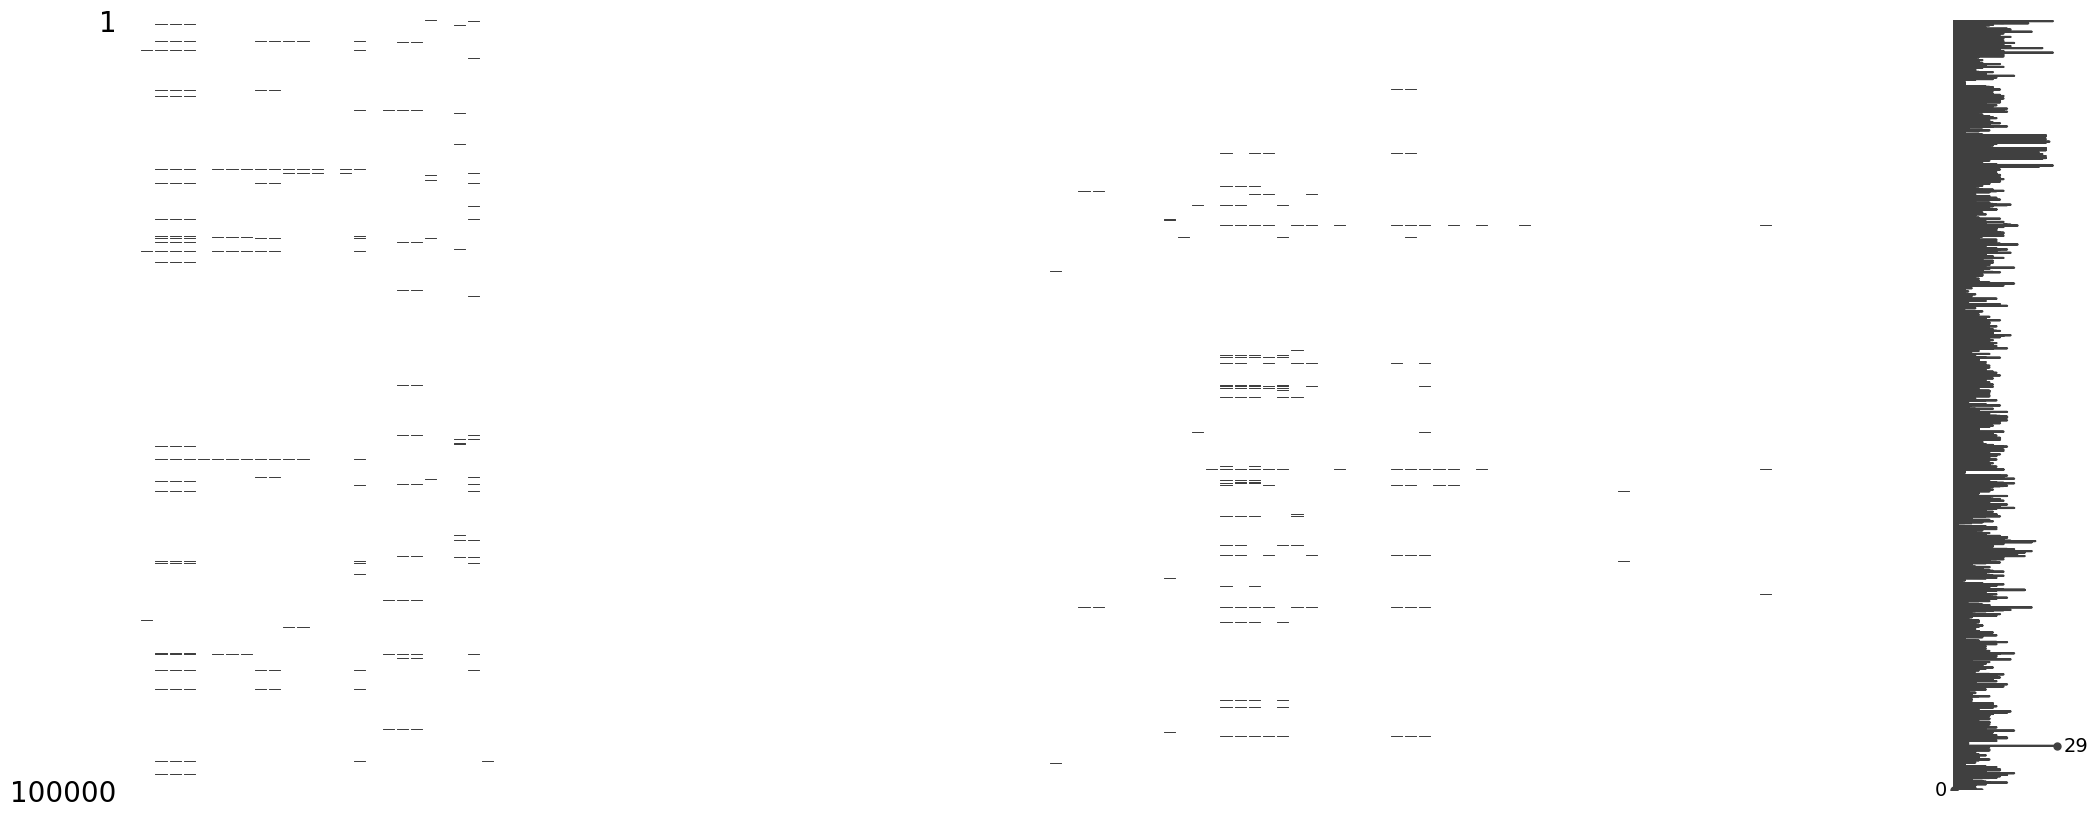

In [7]:
msno.matrix(df[collones_trop_vides])

appercu du nouveau dataset avec collones suffisament remplie

<Axes: >

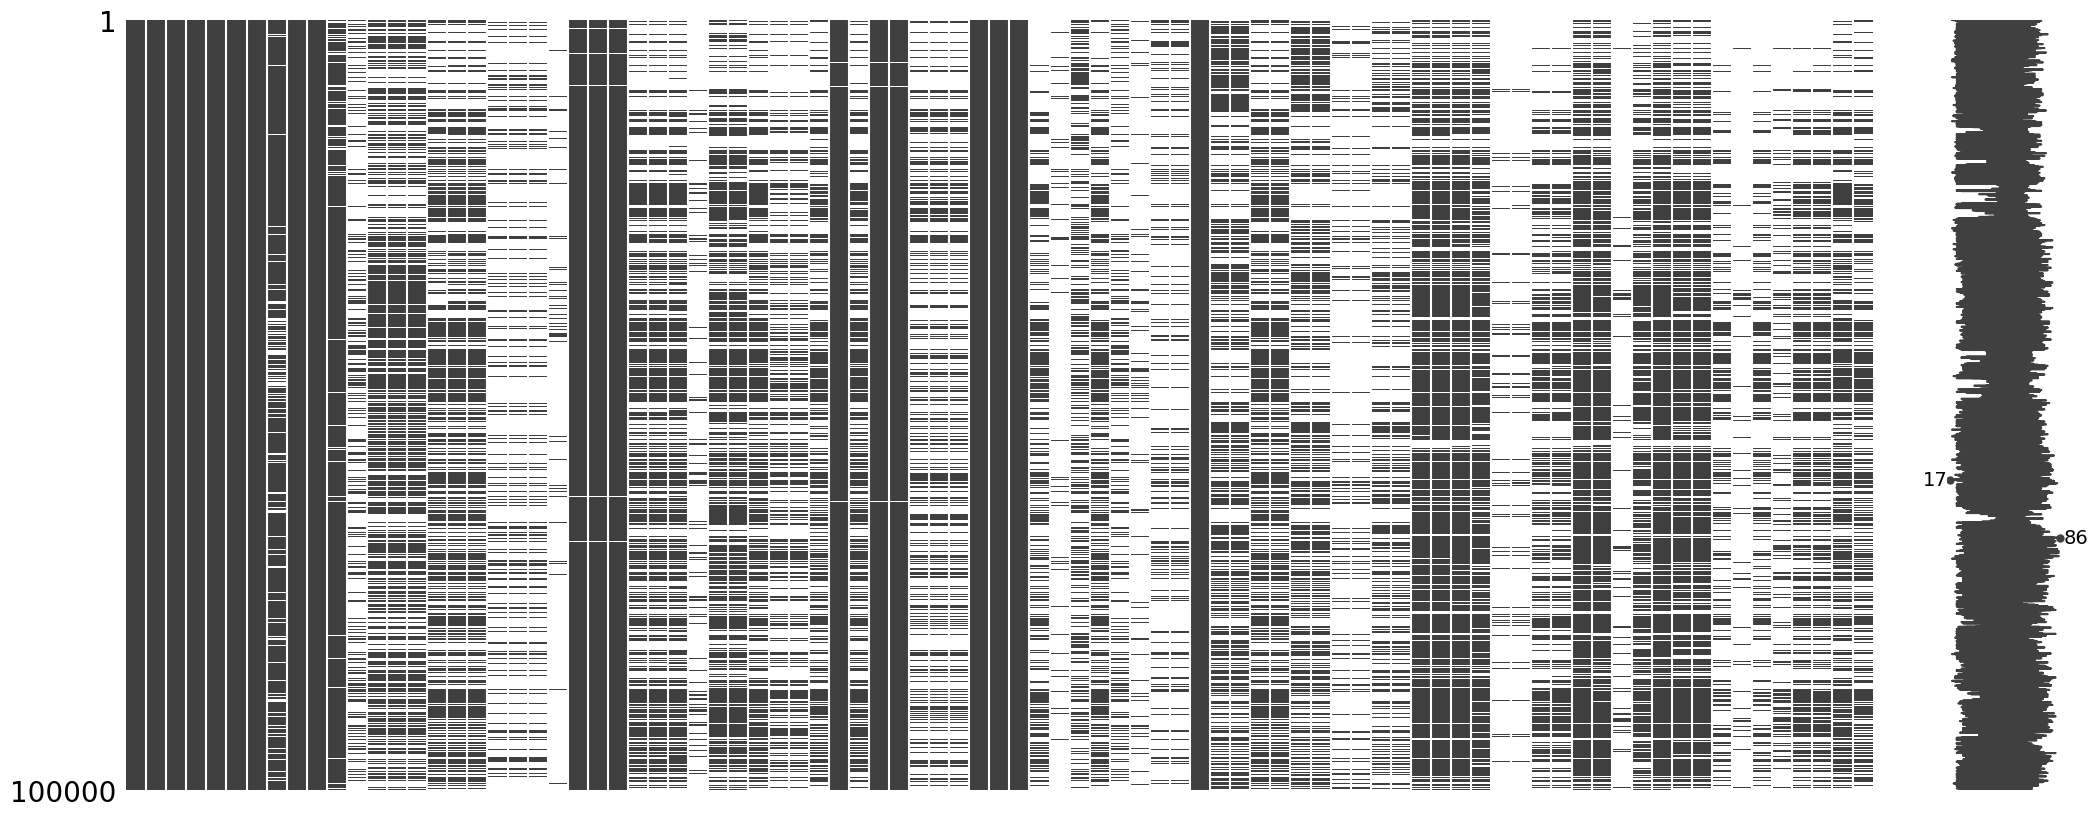

In [8]:
msno.matrix(df_sans_collones_trop_vides)

enregistrement du csv sans collones inutiles avant de le convertir en format parquet

In [9]:
df_sans_collones_trop_vides.to_csv('data/df_no_empty_columns.csv', index=False)

In [10]:
df2 = pd.read_csv('data/df_no_empty_columns.csv', on_bad_lines='skip')

In [11]:
df2.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,salt_100g,sodium_100g,vitamin-a_100g,vitamin-d_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,1.200,0.48,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,0.025,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011335,NaN
4,2,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1722606455,2024-08-02T13:47:35Z,1749171851,2025-06-06T01:04:11Z,altroconsumo,1749171851,2025-06-06T01:04:11Z,...,0.400,0.16,0.0,NaN,0.0,0.0,NaN,0.0001,0.052506,NaN


In [12]:
df2.shape

(100000, 87)

In [13]:
df2.to_parquet('df_pre_cleaned.parquet', engine='pyarrow', compression='snappy')

format parquet

In [14]:
df3 = pd.read_parquet("df_pre_cleaned.parquet", engine='pyarrow')

In [15]:
df3.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,salt_100g,sodium_100g,vitamin-a_100g,vitamin-d_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,None,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,1.200,0.48,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,0.025,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,None,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011335,NaN
4,2,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1722606455,2024-08-02T13:47:35Z,1749171851,2025-06-06T01:04:11Z,altroconsumo,1749171851,2025-06-06T01:04:11Z,...,0.400,0.16,0.0,NaN,0.0,0.0,NaN,0.0001,0.052506,NaN
